Skupaj vzorcev: 2968
Črke: [np.str_('A'), np.str_('B'), np.str_('C'), np.str_('D'), np.str_('E'), np.str_('F'), np.str_('G'), np.str_('H'), np.str_('I'), np.str_('J'), np.str_('K'), np.str_('L'), np.str_('M'), np.str_('N'), np.str_('O'), np.str_('P'), np.str_('R'), np.str_('S'), np.str_('T'), np.str_('U'), np.str_('V'), np.str_('Z'), np.str_('Č'), np.str_('Š'), np.str_('Ž')]
Osebe: [np.str_(',,'), np.str_('1009'), np.str_('232323'), np.str_('69'), np.str_('Ana'), np.str_('Bruih'), np.str_('CritKill'), np.str_('Diablo'), np.str_('Gabor'), np.str_('Gilda Fejniković'), np.str_('Hamorii'), np.str_('Hana'), np.str_('Hnabči'), np.str_('Janez'), np.str_('Janez Januš'), np.str_('Jerry'), np.str_('K'), np.str_('Klara'), np.str_('Ks'), np.str_('Ksenija'), np.str_('Lolek'), np.str_('Lt'), np.str_('Martin'), np.str_('NejcYami'), np.str_('Ok'), np.str_('Petra'), np.str_('Ponižni prevozniki'), np.str_('Pos1'), np.str_('Pos2'), np.str_('Poss'), np.str_('Steve'), np.str_('Tamara'), np.str_('Trupina'),

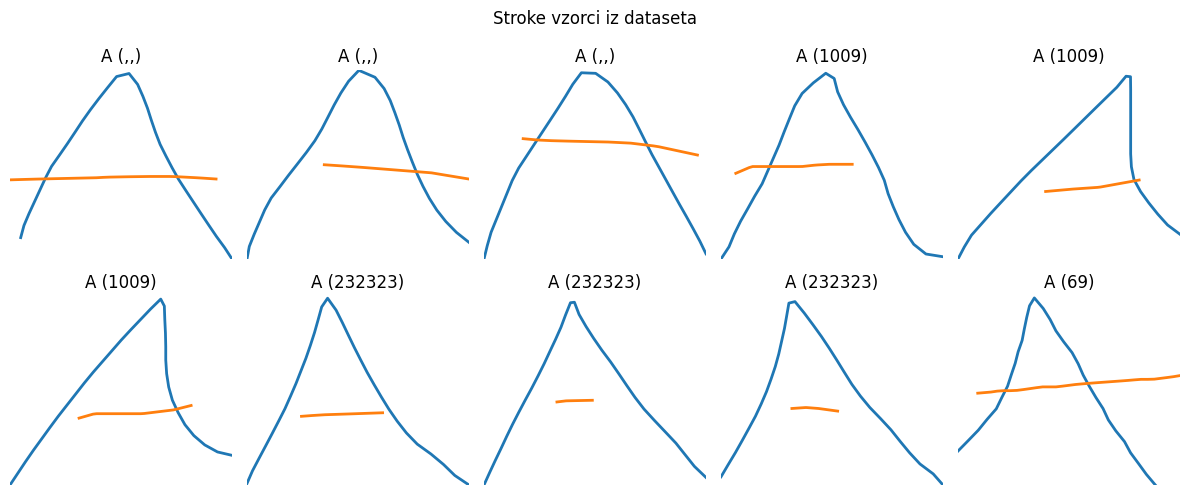

Epoch 1/100
172/172 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.1057 - loss: 2.9764 - val_accuracy: 0.2756 - val_loss: 2.3672
Epoch 2/100
172/172 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.3883 - loss: 1.9064 - val_accuracy: 0.5556 - val_loss: 1.3645
Epoch 3/100
172/172 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.5793 - loss: 1.2884 - val_accuracy: 0.7244 - val_loss: 0.9316
Epoch 4/100
172/172 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.6832 - loss: 1.0313 - val_accuracy: 0.8089 - val_loss: 0.7023
Epoch 5/100
172/172 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.7350 - loss: 0.8575 - val_accuracy: 0.8044 - val_loss: 0.6240
Epoch 6/100
172/172 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.7849 - loss: 0.7345 - val_accuracy: 0.8444 - val_loss: 0.5460
Epoch 7/100
172/172 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8181 - loss: 0.6349 - val_accuracy: 0.8622 - val_loss: 0.4807
Epoch 8/100
172/172 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8308 - loss: 0.5683 - val_accu

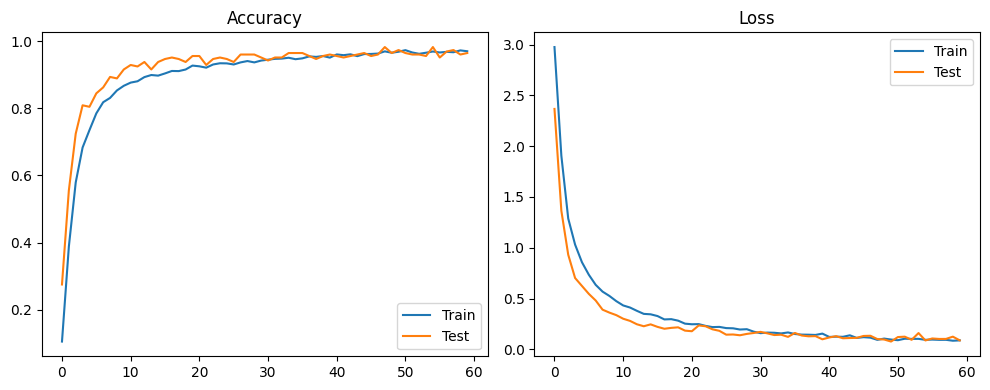

In [1]:
import tensorflow as tf
import numpy as np
import json
import os
import matplotlib.pyplot as plt
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
import struct

# ============================================================
# 1. NASTAVITVE
# ============================================================
STROKE_DIR = r'F:\FRI_DIPLOMSKA\-delovna mapa-\DATASET\dataset\strokes'
MAX_STROKES = 5
POINTS_PER_STROKE = 32
TEST_OSEBE = ['1009', 'pika', 'K']  # osebe za testiranje
FILTER_CRKE = None  # None = vse črke, ali npr. ['A','B'] za samo A in B

# ============================================================
# 2. FUNKCIJE
# ============================================================
def resample_stroke(points, max_strokes=MAX_STROKES, points_per_stroke=POINTS_PER_STROKE):
    strokes = []
    current = []
    for p in points:
        if p['x'] == -1:
            if current:
                strokes.append(current)
                current = []
        else:
            current.append((p['x'], p['y']))
    if current:
        strokes.append(current)
    if not strokes:
        return None

    all_pts = np.array([p for s in strokes for p in s])
    x_min, x_max = all_pts[:,0].min(), all_pts[:,0].max()
    y_min, y_max = all_pts[:,1].min(), all_pts[:,1].max()

    result = np.zeros((max_strokes, points_per_stroke, 2))
    for i, stroke in enumerate(strokes[:max_strokes]):
        if len(stroke) < 2:
            continue
        coords = np.array(stroke)
        distances = np.sqrt(np.sum(np.diff(coords, axis=0)**2, axis=1))
        cumdist = np.concatenate([[0], np.cumsum(distances)])
        total_dist = cumdist[-1]
        if total_dist == 0:
            continue
        sample_points = np.linspace(0, total_dist, points_per_stroke)
        xs = np.interp(sample_points, cumdist, coords[:,0])
        ys = np.interp(sample_points, cumdist, coords[:,1])
        xs = (xs - x_min) / (x_max - x_min + 1e-8)
        ys = (ys - y_min) / (y_max - y_min + 1e-8)
        result[i] = np.column_stack([xs, ys])

    return result.flatten()  # 320 vrednosti

# ============================================================
# 3. NALOŽI PODATKE
# ============================================================
X_all, y_all, osebe_all = [], [], []

for filename in os.listdir(STROKE_DIR):
    if not filename.endswith('.json'):
        continue
    crka = filename[0]
    if FILTER_CRKE and crka not in FILTER_CRKE:
        continue

    parts = filename.split('_')
    oseba = parts[1] if len(parts) > 1 else 'unknown'

    with open(os.path.join(STROKE_DIR, filename), 'r') as f:
        points = json.load(f)

    resampled = resample_stroke(points)
    if resampled is None:
        continue

    X_all.append(resampled)
    y_all.append(crka)
    osebe_all.append(oseba)

X_all = np.array(X_all)
y_all = np.array(y_all)
osebe_all = np.array(osebe_all)

print(f"Skupaj vzorcev: {len(X_all)}")
print(f"Črke: {sorted(set(y_all))}")
print(f"Osebe: {sorted(set(osebe_all))}")

# ============================================================
# 4. TRAIN/TEST SPLIT PO OSEBAH
# ============================================================
train_mask = ~np.isin(osebe_all, TEST_OSEBE)
test_mask = np.isin(osebe_all, TEST_OSEBE)

X_train = X_all[train_mask]
y_train = y_all[train_mask]
X_test = X_all[test_mask]
y_test = y_all[test_mask]

print(f"\nTrain: {X_train.shape} — {np.unique(osebe_all[train_mask])}")
print(f"Test:  {X_test.shape} — {np.unique(osebe_all[test_mask])}")


labels_ordered = ['A', 'B', 'C', 'Č', 'D', 'E', 'F', 'G', 'H', 'I',
                  'J', 'K', 'L', 'M', 'N', 'O', 'P', 'R', 'S', 'Š',
                  'T', 'U', 'V', 'Z', 'Ž']
label_to_idx = {l: i for i, l in enumerate(labels_ordered)}
n_classes = len(labels_ordered)

y_train_enc = np.array([label_to_idx[c] for c in y_train])
y_test_enc  = np.array([label_to_idx[c] for c in y_test])
print(f"Razredi: {labels_ordered}")
# ============================================================
# 5. VIZUALIZACIJA VZORCEV
# ============================================================
fig, axes = plt.subplots(2, 5, figsize=(12, 5))
for i in range(min(10, len(X_all))):
    data = X_all[i].reshape(5, 32, 2)
    for stroke in data:
        if stroke.sum() == 0:
            continue
        axes[i//5][i%5].plot(stroke[:,0], 1-stroke[:,1], linewidth=2)
    axes[i//5][i%5].set_title(f'{y_all[i]} ({osebe_all[i]})')
    axes[i//5][i%5].set_xlim(0, 1)
    axes[i//5][i%5].set_ylim(0, 1)
    axes[i//5][i%5].axis('off')
plt.suptitle('Stroke vzorci iz dataseta')
plt.tight_layout()
plt.show()

# ============================================================
# 6. MODEL - pravilna arhitektura za stroke podatke
# ============================================================
n_classes = len(labels_ordered)

inputs = tf.keras.layers.Input(shape=(320,))

# Reshape v (5 strokeov, 64 vrednosti) — vsak stroke je svoja "vrstica"
x = tf.keras.layers.Reshape((5, 64))(inputs)  # 5 × (32točk × 2koordinati)

# Conv1D zdaj gleda vzdolž strokeov, ne čez koordinate
x = tf.keras.layers.Conv1D(32, 3, activation='relu', padding='same')(x)
x = tf.keras.layers.Conv1D(64, 3, activation='relu', padding='same')(x)
x = tf.keras.layers.GlobalAveragePooling1D()(x)

x = tf.keras.layers.Dense(64, activation='relu')(x)
x = tf.keras.layers.Dropout(0.3)(x)
x = tf.keras.layers.Dense(32, activation='relu')(x)
x = tf.keras.layers.Dense(n_classes, activation='softmax')(x)

stroke_model = tf.keras.Model(inputs, x)

stroke_model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

# ============================================================
# 7. TRENING
# ============================================================
early_stop = tf.keras.callbacks.EarlyStopping(
    patience=10,
    restore_best_weights=True,
    verbose=1
)

history = stroke_model.fit(
    X_train, y_train_enc,
    epochs=100,
    batch_size=16,
    validation_data=(X_test, y_test_enc),
    callbacks=[early_stop],
    verbose=1
)

# ============================================================
# 8. REZULTATI
# ============================================================
_, train_acc = stroke_model.evaluate(X_train, y_train_enc, verbose=0)
_, test_acc = stroke_model.evaluate(X_test, y_test_enc, verbose=0)
print(f"\nTrain accuracy: {train_acc*100:.1f}%")
print(f"Test accuracy:  {test_acc*100:.1f}%")

# Graf
plt.figure(figsize=(10, 4))
plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Train')
plt.plot(history.history['val_accuracy'], label='Test')
plt.title('Accuracy')
plt.legend()
plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Train')
plt.plot(history.history['val_loss'], label='Test')
plt.title('Loss')
plt.legend()
plt.tight_layout()
plt.show()



In [2]:
# ============================================================
# 10. PRETVORBA V TFLITE (z optimizacijo za mikrokontrolerje)
# ============================================================
converter = tf.lite.TFLiteConverter.from_keras_model(stroke_model)

# Osnovna pretvorba
tflite_model = converter.convert()
with open(r'F:\FRI_DIPLOMSKA\-delovna mapa-\MODEL\strokes\strokes.tflite', 'wb') as f:
    f.write(tflite_model)

# ŠE BOLJE: Kvantizacija (INT8 ali Float16) za hitrejši STM32
converter.optimizations = [tf.lite.Optimize.DEFAULT]
tflite_quant_model = converter.convert()
with open(r'F:\FRI_DIPLOMSKA\-delovna mapa-\MODEL\strokes\strokes2.tflite', 'wb') as f:
    f.write(tflite_quant_model)

print("TFLite modela (navaden in kvantiziran) shranjena!")

INFO:tensorflow:Assets written to: C:\Users\Ksenija\AppData\Local\Temp\tmp9f5phudl\assets


INFO:tensorflow:Assets written to: C:\Users\Ksenija\AppData\Local\Temp\tmp9f5phudl\assets


Saved artifact at 'C:\Users\Ksenija\AppData\Local\Temp\tmp9f5phudl'. The following endpoints are available:

* Endpoint 'serve'
  args_0 (POSITIONAL_ONLY): TensorSpec(shape=(None, 320), dtype=tf.float32, name='keras_tensor')
Output Type:
  TensorSpec(shape=(None, 25), dtype=tf.float32, name=None)
Captures:
  1737863789264: TensorSpec(shape=(), dtype=tf.resource, name=None)
  1737863790416: TensorSpec(shape=(), dtype=tf.resource, name=None)
  1737863789648: TensorSpec(shape=(), dtype=tf.resource, name=None)
  1737863790032: TensorSpec(shape=(), dtype=tf.resource, name=None)
  1737863789840: TensorSpec(shape=(), dtype=tf.resource, name=None)
  1737863786192: TensorSpec(shape=(), dtype=tf.resource, name=None)
  1737877782800: TensorSpec(shape=(), dtype=tf.resource, name=None)
  1737877783376: TensorSpec(shape=(), dtype=tf.resource, name=None)
  1737877784528: TensorSpec(shape=(), dtype=tf.resource, name=None)
  1737877783760: TensorSpec(shape=(), dtype=tf.resource, name=None)
INFO:tensorf

INFO:tensorflow:Assets written to: C:\Users\Ksenija\AppData\Local\Temp\tmpmhkraq20\assets


Saved artifact at 'C:\Users\Ksenija\AppData\Local\Temp\tmpmhkraq20'. The following endpoints are available:

* Endpoint 'serve'
  args_0 (POSITIONAL_ONLY): TensorSpec(shape=(None, 320), dtype=tf.float32, name='keras_tensor')
Output Type:
  TensorSpec(shape=(None, 25), dtype=tf.float32, name=None)
Captures:
  1737863789264: TensorSpec(shape=(), dtype=tf.resource, name=None)
  1737863790416: TensorSpec(shape=(), dtype=tf.resource, name=None)
  1737863789648: TensorSpec(shape=(), dtype=tf.resource, name=None)
  1737863790032: TensorSpec(shape=(), dtype=tf.resource, name=None)
  1737863789840: TensorSpec(shape=(), dtype=tf.resource, name=None)
  1737863786192: TensorSpec(shape=(), dtype=tf.resource, name=None)
  1737877782800: TensorSpec(shape=(), dtype=tf.resource, name=None)
  1737877783376: TensorSpec(shape=(), dtype=tf.resource, name=None)
  1737877784528: TensorSpec(shape=(), dtype=tf.resource, name=None)
  1737877783760: TensorSpec(shape=(), dtype=tf.resource, name=None)
TFLite model

**Pretvorba v .bin file da ga bomo dali na vezje**


In [3]:
# import numpy as np

# # Seznam črk točno v takem vrstnem redu, kot ga imaš v SLO_ABECEDA v C kodi
# labels_ordered = ['A', 'B', 'C', 'Č', 'D', 'E', 'F', 'G', 'H', 'I',
#                   'J', 'K', 'L', 'M', 'N', 'O', 'P', 'R', 'S', 'Š',
#                   'T', 'U', 'V', 'Z', 'Ž']

# # Ustvarimo mapiranje: 'A' -> 0, 'B' -> 1, ...
# label_to_idx = {l: i for i, l in enumerate(labels_ordered)}

# def export_benchmark_data(X, y, filename=r'F:\FRI_DIPLOMSKA\-delovna mapa-\MODEL\strokes\zbirka_strokes.bin'):
#     with open(filename, "wb") as f:
#         for i in range(len(X)):
#             # 1. Pretvori črko v številko (npr. 'Č' -> 3)
#             char_label = str(y[i])
#             if char_label not in label_to_idx:
#                 print(f"Opozorilo: Črka {char_label} ni v seznamu! Preskakujem.")
#                 continue
            
#             numeric_label = label_to_idx[char_label]
            
#             # 2. Pripravi točke (X_test so že floati med 0 in 1 ali podobno)
#             # Uporabimo float32, ker AI model v C-ju to pričakuje
#             points = X[i].astype(np.float32) 
            
#             # 3. Zapakiraj (B=uint8, H=uint16, 320f=320 floatov)
#             # Skupaj: 1 + 2 + (320 * 4) = 1283 bajtov na vzorec
#             data = struct.pack(f'<BH320f', numeric_label, 160, *points)
#             f.write(data)
            
#     print(f"Končano! Ustvarjena datoteka '{filename}' s {len(X)} vzorci.")

# # Zaženi
# export_benchmark_data(X_test, y_test)

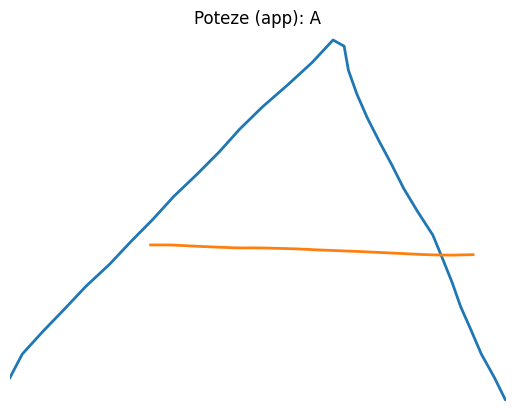

In [4]:
a_indices = np.where(y_all == 'A')[0]
a_idx = np.random.choice(a_indices)

data = X_all[a_idx].reshape(5, 32, 2)
for stroke in data:
    if stroke.sum() == 0:
        continue
    plt.plot(stroke[:,0], 1-stroke[:,1], linewidth=2)
plt.title(f"Poteze (app): A")
plt.xlim(0, 1)
plt.ylim(0, 1)
plt.axis('off')
plt.show()

In [5]:
print(f"Skupaj vzorcev: {len(X_all)}")

Skupaj vzorcev: 2968
